# AIML Lab 6 - Predict Disease Risk from Patient Data

Dataset: Pima Indians Diabetes (`diabetes.csv`)

## Part A - Import and Explore Patient Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, RocCurveDisplay)

In [2]:
df = pd.read_csv("diabetes.csv")
print("Dataset Imported Successfully.")
df.head()

Dataset Imported Successfully.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print("Number of Patient Records:", df.shape[0])
print("Number of Input Features:", df.shape[1] - 1)

Number of Patient Records: 768
Number of Input Features: 8


In [4]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [5]:
counts = df["Outcome"].value_counts().sort_index()
print("Target Class Distribution:")
print("0 - No Diabetes:", counts[0])
print("1 - Diabetes:", counts[1])

Target Class Distribution:
0 - No Diabetes: 500
1 - Diabetes: 268


In [6]:
X = df.drop(columns="Outcome")
y = df["Outcome"]
print("X:", X.shape, " y:", y.shape)

X: (768, 8)  y: (768,)


## Part B - Preprocess and Engineer Features

In [7]:
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

print("Zero (invalid) values before preprocessing:")
print((X[zero_cols] == 0).sum())

X = X.copy()
X[zero_cols] = X[zero_cols].replace(0, np.nan)

Zero (invalid) values before preprocessing:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Training Records:", len(X_train))
print("Testing Records:", len(X_test))

Training Records: 614
Testing Records: 154


In [9]:
# medians and scaler are learned from the training set only
medians = X_train.median()
X_train = X_train.fillna(medians)
X_test = X_test.fillna(medians)

print("Missing values left - train:", int(X_train.isnull().sum().sum()),
      " test:", int(X_test.isnull().sum().sum()))
print("Missing Values Handled Successfully.")

Missing values left - train: 0  test: 0
Missing Values Handled Successfully.


In [10]:
features = list(X.columns)
scaler = StandardScaler()

X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=features, index=X_train.index)
X_test_s = pd.DataFrame(scaler.transform(X_test), columns=features, index=X_test.index)

X_train_s["Age_BMI_Interaction"] = X_train_s["Age"] * X_train_s["BMI"]
X_test_s["Age_BMI_Interaction"] = X_test_s["Age"] * X_test_s["BMI"]

print("Feature Engineering Completed.")
X_train_s.head()

Feature Engineering Completed.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Age_BMI_Interaction
353,-0.851355,-1.056427,-0.826740,-1.918187,-1.203361,-0.769694,0.310794,-0.792169,0.609728
711,0.356576,0.144399,0.477772,-0.229874,-1.470195,-0.417714,-0.116439,0.561034,-0.234352
373,-0.549372,-0.556083,-1.152868,1.233330,-0.555335,0.359576,-0.764862,-0.707594,-0.254434
46,-0.851355,0.811525,-1.315932,-0.004766,-0.161437,-0.403048,0.262314,-0.369293,0.148843
682,-1.153338,-0.889646,-0.663676,1.120776,-0.415565,1.782163,-0.337630,-0.961320,-1.713229


In [11]:
print("Processed training set:", X_train_s.shape)
print("Processed testing set:", X_test_s.shape)
print("Processed Dataset Ready for Model Training.")

Processed training set: (614, 9)
Processed testing set: (154, 9)
Processed Dataset Ready for Model Training.


## Part C - Train and Compare Classification Models

In [12]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print("MODEL COMPARISON")
print("-" * 40)
for name, model in models.items():
    scores = cross_validate(model, X_train_s, y_train, cv=cv, scoring=["accuracy", "roc_auc"])
    cv_results[name] = scores
    print()
    print(name)
    print(f"Mean CV Accuracy : {scores['test_accuracy'].mean():.4f}")
    print(f"Mean CV ROC-AUC  : {scores['test_roc_auc'].mean():.4f}")

best_name = max(cv_results, key=lambda n: cv_results[n]["test_roc_auc"].mean())
print()
print("Selected Model:", best_name)

MODEL COMPARISON
----------------------------------------

Logistic Regression
Mean CV Accuracy : 0.7866
Mean CV ROC-AUC  : 0.8424



Random Forest
Mean CV Accuracy : 0.7492
Mean CV ROC-AUC  : 0.8211

Selected Model: Logistic Regression


In [13]:
for model in models.values():
    model.fit(X_train_s, y_train)

best_model = models[best_name]

## Part D - Predict Diabetes Status for a New Patient

In [14]:
new_patient = pd.DataFrame([{
    "Pregnancies": 2, "Glucose": 150, "BloodPressure": 80, "SkinThickness": 30,
    "Insulin": 100, "BMI": 32.0, "DiabetesPedigreeFunction": 0.5, "Age": 45,
}])

new_patient[zero_cols] = new_patient[zero_cols].replace(0, np.nan)
new_patient = new_patient.fillna(medians)
new_s = pd.DataFrame(scaler.transform(new_patient), columns=features)
new_s["Age_BMI_Interaction"] = new_s["Age"] * new_s["BMI"]

prob = best_model.predict_proba(new_s)[0, 1]
pred = int(prob >= 0.5)

print("NEW PATIENT CLASSIFICATION")
print("-" * 40)
print("Predicted Diabetes Status:", "Diabetes" if pred else "No Diabetes")
print(f"Estimated Probability of Positive Class: {prob:.4f}")

NEW PATIENT CLASSIFICATION
----------------------------------------
Predicted Diabetes Status: Diabetes
Estimated Probability of Positive Class: 0.5423


## Part E - Evaluate the Selected Model

In [15]:
rows = []
for name, model in models.items():
    p = model.predict(X_test_s)
    prob_test = model.predict_proba(X_test_s)[:, 1]
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, p),
        "Precision": precision_score(y_test, p),
        "Recall": recall_score(y_test, p),
        "F1-Score": f1_score(y_test, p),
        "ROC-AUC": roc_auc_score(y_test, prob_test),
    })

pd.DataFrame(rows).set_index("Model").round(4)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.7013,0.5870,0.500,0.5400,0.8133
Random Forest,0.7403,0.6591,0.537,0.5918,0.8131


In [16]:
y_pred = best_model.predict(X_test_s)

print(best_name, "- test set")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=["No Diabetes", "Diabetes"]))

Logistic Regression - test set
Confusion Matrix:
[[81 19]
 [27 27]]

              precision    recall  f1-score   support

 No Diabetes       0.75      0.81      0.78       100
    Diabetes       0.59      0.50      0.54        54

    accuracy                           0.70       154
   macro avg       0.67      0.66      0.66       154
weighted avg       0.69      0.70      0.70       154



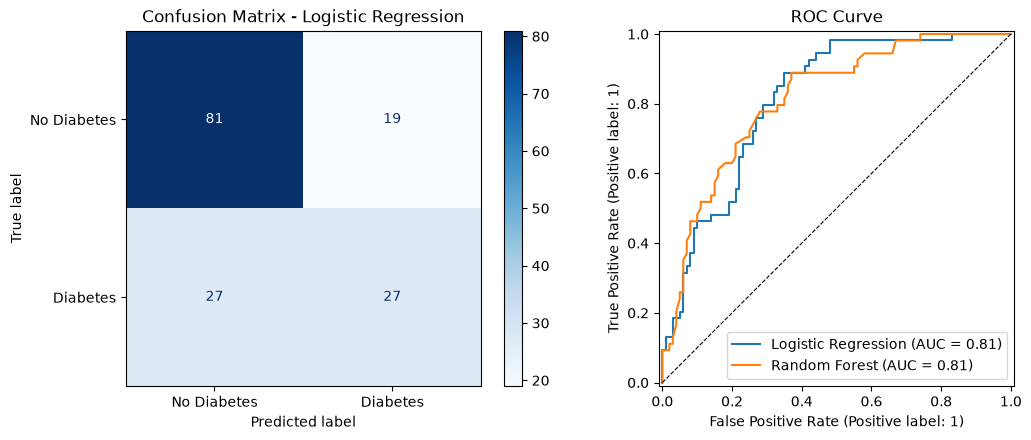

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["No Diabetes", "Diabetes"], cmap="Blues", ax=axes[0]
)
axes[0].set_title(f"Confusion Matrix - {best_name}")

for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test_s, y_test, name=name, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", linewidth=0.8)
axes[1].set_title("ROC Curve")

plt.tight_layout()
plt.show()

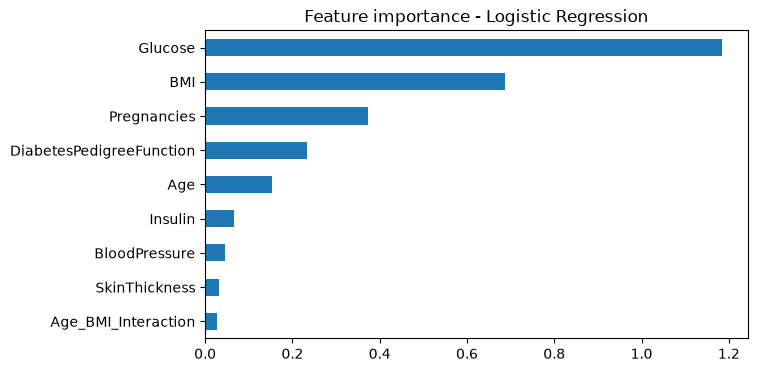

In [18]:
if best_name == "Random Forest":
    imp = pd.Series(best_model.feature_importances_, index=X_train_s.columns)
else:
    imp = pd.Series(np.abs(best_model.coef_[0]), index=X_train_s.columns)

imp.sort_values().plot(kind="barh", figsize=(7, 4), title=f"Feature importance - {best_name}")
plt.show()

**Interpretation:** Logistic Regression was selected because it had the higher mean CV ROC-AUC
(0.842 vs 0.821). On the test set both models have almost the same ROC-AUC (about 0.813), but
Random Forest got better accuracy and F1 at the 0.5 threshold. Both models miss around half of the
diabetic patients (recall 0.50 to 0.54), so the threshold would need to be lowered if this was used
for screening, where missing a positive case is worse than a false alarm. Glucose is the most
important feature for the selected model.

## Part F - Industry-Oriented Application

Patient Health Records -> Data Validation -> Missing-Value Handling -> Feature Engineering
-> Trained ML Model -> Diabetes Status Estimation -> Healthcare Professional Review

In [19]:
def screen_patient(record):
    patient = pd.DataFrame([record])[features]
    patient[zero_cols] = patient[zero_cols].replace(0, np.nan)
    patient = patient.fillna(medians)
    s = pd.DataFrame(scaler.transform(patient), columns=features)
    s["Age_BMI_Interaction"] = s["Age"] * s["BMI"]
    p = best_model.predict_proba(s)[0, 1]
    return {"probability": round(p, 4),
            "status": "Diabetes" if p >= 0.5 else "No Diabetes",
            "action": "refer for clinician review" if p >= 0.5 else "routine follow-up"}


batch = [
    {"Pregnancies": 2, "Glucose": 150, "BloodPressure": 80, "SkinThickness": 30,
     "Insulin": 100, "BMI": 32.0, "DiabetesPedigreeFunction": 0.5, "Age": 45},
    {"Pregnancies": 1, "Glucose": 95, "BloodPressure": 70, "SkinThickness": 20,
     "Insulin": 80, "BMI": 24.0, "DiabetesPedigreeFunction": 0.2, "Age": 28},
    {"Pregnancies": 6, "Glucose": 180, "BloodPressure": 0, "SkinThickness": 0,
     "Insulin": 0, "BMI": 38.5, "DiabetesPedigreeFunction": 1.1, "Age": 55},
]

pd.DataFrame([screen_patient(r) for r in batch])

,probability,status,action
0,0.5423,Diabetes,refer for clinician review
1,0.0350,No Diabetes,routine follow-up
2,0.9554,Diabetes,refer for clinician review
